# Welcome

This is a notebook companying the paper
**In Defense of Using Worst-case Privacy Disclosure as Evaluation Metric of Voice Anonymization**

The notebook is easy to run.

* Dependency: the default numpy and scipy should be sufficient
* Usage:
    * Run Function def.
    * Go the demonstration part and run

The notebook will download and use data from VPC. Simulated data will also be used.

In [ ]:
import numpy as np
import scipy

# Function def.

Supporting functions needed to compute metrics.

We will import existing tools created by others.

```bash
Python Function from min tDCF on asvspoof.org
licensed by Creative Commons.

----- License ----
This work is licensed under the Creative Commons
Attribution-NonCommercial-ShareAlike 4.0 International
License. To view a copy of this license, visit
http://creativecommons.org/licenses/by-nc-sa/4.0/
or send a letter to
Creative Commons, 444 Castro Street, Suite 900,
Mountain View, California, 94041, USA.
------------------
```

In [ ]:
# EER


def compute_det_curve(target_scores, nontarget_scores):
    """
    frr, far, thr = compute_det_curve(target_scores, nontarget_scores)

    input
    -----
      target_scores:    np.array, target trial scores
      nontarget_scores: np.array, nontarget trial scores

    output
    ------
      frr:   np.array, FRR, (#N, ), where #N is total number of scores + 1
      far:   np.array, FAR, (#N, ), where #N is total number of scores + 1
      thr:   np.array, threshold, (#N, )

    """

    n_scores = target_scores.size + nontarget_scores.size
    all_scores = np.concatenate((target_scores, nontarget_scores))
    labels = np.concatenate((np.ones(target_scores.size),
                             np.zeros(nontarget_scores.size)))

    # Sort labels based on scores
    indices = np.argsort(all_scores, kind='mergesort')
    labels = labels[indices]

    # Compute false rejection and false acceptance rates
    tar_trial_sums = np.cumsum(labels)
    nontarget_trial_sums = (nontarget_scores.size -
                            (np.arange(1, n_scores + 1) - tar_trial_sums))

    frr = np.concatenate((np.atleast_1d(0), tar_trial_sums/target_scores.size))
    # false rejection rates
    far = np.concatenate((np.atleast_1d(1),
                          nontarget_trial_sums / nontarget_scores.size))
    # false acceptance rates
    thresholds = np.concatenate((np.atleast_1d(all_scores[indices[0]] - 0.001),
                                 all_scores[indices]))
    # Thresholds are the sorted scores
    return frr, far, thresholds


def compute_eer(target_scores, nontarget_scores):
    """
    eer, eer_threshold = compute_eer(target_scores, nontarget_scores)

    input
    -----
      target_scores:    np.array, target trial scores
      nontarget_scores: np.array, nontarget trial scores

    output
    ------
      eer:            float, EER
      eer_threshold:  float, threshold corresponding to EER

    """
    frr, far, thr = compute_det_curve(target_scores, nontarget_scores)

    # find the operation point for EER
    abs_diffs = np.abs(frr - far)
    min_index = np.argmin(abs_diffs)

    # compute EER
    eer = np.mean((frr[min_index], far[min_index]))
    return eer, thr[min_index]



In [ ]:
"""
This module is based on Cllr and min Cllr implemented by Dr. Andreas Nautsch

https://gitlab.eurecom.fr/nautsch/cllr

license: LGPLv3
version: 2020-01-10
author: Andreas Nautsch (EURECOM)
"""

import numpy
import copy

def logit(p):
    """logit function.
    This is a one-to-one mapping from probability to log-odds.
    i.e. it maps the interval (0,1) to the real line.
    The inverse function is given by SIGMOID.

    log_odds = logit(p) = log(p/(1-p))

    :param p: the inumpyut value

    :return: logit(inumpyut)
    """
    p = numpy.array(p)
    lp = numpy.zeros(p.shape)
    f0 = p == 0
    f1 = p == 1
    f = (p > 0) & (p < 1)

    if lp.shape == ():
        if f:
            lp = numpy.log(p / (1 - p))
        elif f0:
            lp = -numpy.inf
        elif f1:
            lp = numpy.inf
    else:
        lp[f] = numpy.log(p[f] / (1 - p[f]))
        lp[f0] = -numpy.inf
        lp[f1] = numpy.inf
    return lp


def sigmoid(log_odds):
    """SIGMOID: Inverse of the logit function.
    This is a one-to-one mapping from log odds to probability.
    i.e. it maps the real line to the interval (0,1).

    p = sigmoid(log_odds)

    :param log_odds: the inumpyut value

    :return: sigmoid(inumpyut)
    """
    p = 1 / (1 + numpy.exp(-log_odds))
    return p

def pavx(y):
    """PAV: Pool Adjacent Violators algorithm.
    Non-paramtetric optimization subject to monotonicity.

    ghat = pav(y)
    fits a vector ghat with nondecreasing components to the
    data vector y such that sum((y - ghat).^2) is minimal.
    (Pool-adjacent-violators algorithm).

    optional outputs:
            width: width of pav bins, from left to right
                    (the number of bins is data dependent)
            height: corresponding heights of bins (in increasing order)

    Author: This code is a simplified version of the 'IsoMeans.m' code
    made available by Lutz Duembgen at:
    http://www.imsv.unibe.ch/~duembgen/software

    :param y: inumpyut value
    """
    assert y.ndim == 1, 'Argument should be a 1-D array'
    assert y.shape[0] > 0, 'Inumpyut array is empty'
    n = y.shape[0]

    index = numpy.zeros(n, dtype=int)
    length = numpy.zeros(n, dtype=int)

    ghat = numpy.zeros(n)

    ci = 0
    index[ci] = 1
    length[ci] = 1
    ghat[ci] = y[0]

    for j in range(1, n):
        ci += 1
        index[ci] = j + 1
        length[ci] = 1
        ghat[ci] = y[j]
        while (ci >= 1) & (ghat[numpy.max(ci - 1, 0)] >= ghat[ci]):
            nw = length[ci - 1] + length[ci]
            ghat[ci - 1] = ghat[ci - 1] + (length[ci] / nw) * (ghat[ci] - ghat[ci - 1])
            length[ci - 1] = nw
            ci -= 1

    height = copy.deepcopy(ghat[:ci + 1])
    width = copy.deepcopy(length[:ci + 1])

    while n >= 0:
        for j in range(index[ci], n + 1):
            ghat[j - 1] = ghat[ci]
        n = index[ci] - 1
        ci -= 1

    return ghat, width, height


def optimal_llr(tar, non, laplace=False,
                monotonicity_epsilon=1e-6, compute_eer=False):
    """

    input
    -----
      tar_llrs:    np.array (N, ), null hypothesis LLRs
      nontar_llrs: np.array (M, ), alter hypothesis LLRs
      laplace:     bool,

    output
    ------
      c: scalar, Cllr value

    Comment by original author:
    Laplace flag avoids infinite LLR magnitudes;
    also, this stops DET cureves from 'curling' to the axes on sparse data
    (DETs stay in more populated regions)
    """

    scores = numpy.concatenate([non, tar])
    Pideal = numpy.concatenate([numpy.zeros(len(non)), numpy.ones(len(tar))])

    perturb = numpy.argsort(scores, kind='mergesort')
    Pideal = Pideal[perturb]

    if laplace:
        Pideal = numpy.hstack([1, 0, Pideal, 1, 0])

    Popt, width, foo = pavx(Pideal)

    if laplace:
        Popt = Popt[2:len(Popt) - 2]

    posterior_log_odds = logit(Popt)
    log_prior_odds = numpy.log(len(tar) / len(non))
    llrs = posterior_log_odds - log_prior_odds
    N = len(tar) + len(non)
    llrs = llrs + numpy.arange(N) * monotonicity_epsilon / N  # preserve monotonicity

    idx_reverse = numpy.zeros(len(scores), dtype=int)
    idx_reverse[perturb] = numpy.arange(len(scores))
    tar_llrs = llrs[idx_reverse][len(non):]
    nontar_llrs = llrs[idx_reverse][:len(non)]

    if not compute_eer:
        return tar_llrs, nontar_llrs

    nbins = width.shape[0]
    pmiss = numpy.zeros(nbins + 1)
    pfa = numpy.zeros(nbins + 1)
    #
    # threshold leftmost: accept everything, miss nothing
    left = 0  # 0 scores to left of threshold
    fa = non.shape[0]
    miss = 0
    #
    for i in range(nbins):
        pmiss[i] = miss / len(tar)
        pfa[i] = fa /len(non)
        left = int(left + width[i])
        miss = numpy.sum(Pideal[:left])
        fa = len(tar) + len(non) - left - numpy.sum(Pideal[left:])
    #
    pmiss[nbins] = miss / len(tar)
    pfa[nbins] = fa / len(non)

    eer = 0
    for i in range(pfa.shape[0] - 1):
        xx = pfa[i:i + 2]
        yy = pmiss[i:i + 2]

        # xx and yy should be sorted:
        assert (xx[1] <= xx[0]) & (yy[0] <= yy[1]), \
            'pmiss and pfa have to be sorted'

        XY = numpy.column_stack((xx, yy))
        dd = numpy.dot(numpy.array([1, -1]), XY)
        if numpy.min(numpy.abs(dd)) == 0:
            eerseg = 0
        else:
            # find line coefficients seg s.t. seg'[xx(i);yy(i)] = 1,
            # when xx(i),yy(i) is on the line.
            seg = numpy.linalg.solve(XY, numpy.array([[1], [1]]))
            # candidate for EER, eer is highest candidate
            eerseg = 1 / (numpy.sum(seg))

        eer = max([eer, eerseg])
    return tar_llrs, nontar_llrs, eer




# Demonstration 1 -- PAV

Example of PAV

In [ ]:
# Case 1, no laplacian smoothing

# sample scores
tar_scores = np.array([0.2, 0.4, 0.6])
non_scores = np.array([0.1, 0.3, 0.5])

# compute PAV
sort_order = np.argsort(np.concatenate([tar_scores, non_scores]))
tar_llrs, non_llrs = optimal_llr(tar_scores, non_scores, laplace=False, monotonicity_epsilon=0)

# print results
print("Sorted score:     ", np.concatenate([tar_scores, non_scores])[sort_order])
print("Target P(H_tar|s):", np.concatenate([np.ones_like(tar_scores), np.zeros_like(non_scores)])[sort_order])
print("PAVed LLR:        ", np.concatenate([tar_llrs, non_llrs])[sort_order])


Sorted score:      [0.1 0.2 0.3 0.4 0.5 0.6]
Target P(H_tar|s): [0. 1. 0. 1. 0. 1.]
PAVed LLR:         [-inf   0.   0.   0.   0.  inf]


In [ ]:
# with laplacian
tar_llrs, non_llrs = optimal_llr(tar_scores, non_scores, laplace=True, monotonicity_epsilon=0)
print("Sorted score:     ", np.concatenate([tar_scores, non_scores])[sort_order])
print("Target P(H_tar|s):", np.concatenate([np.ones_like(tar_scores), np.zeros_like(non_scores)])[sort_order])
print("Smoothed LLR:     ", np.concatenate([tar_llrs, non_llrs])[sort_order])

# note that np.log(2) = 0.693147


Sorted score:      [0.1 0.2 0.3 0.4 0.5 0.6]
Target P(H_tar|s): [0. 1. 0. 1. 0. 1.]
Smoothed LLR:      [-0.69314718  0.          0.          0.          0.          0.69314718]


In [ ]:
# Interestingly, if we swap the labels
# no inf!
tar_scores = np.array([0.1, 0.3, 0.5])
non_scores = np.array([0.2, 0.4, 0.6])
sort_order = np.argsort(np.concatenate([tar_scores, non_scores]))
tar_llrs, non_llrs = optimal_llr(tar_scores, non_scores, laplace=True, monotonicity_epsilon=0)
print("Sorted score:     ", np.concatenate([tar_scores, non_scores])[sort_order])
print("Target P(H_tar|s):", np.concatenate([np.ones_like(tar_scores), np.zeros_like(non_scores)])[sort_order])
print("Smoothed LLR:     ", np.concatenate([tar_llrs, non_llrs])[sort_order])


Sorted score:      [0.1 0.2 0.3 0.4 0.5 0.6]
Target P(H_tar|s): [1. 0. 1. 0. 1. 0.]
Smoothed LLR:      [0. 0. 0. 0. 0. 0.]


In [ ]:
# Let repeat the example and make them longer
tar_scores = np.array(np.arange(100) * 2 + 1)
non_scores = np.array(np.arange(100) * 2 )

sort_order = np.argsort(np.concatenate([tar_scores, non_scores]))

tar_llrs, non_llrs = optimal_llr(tar_scores, non_scores, laplace=True, monotonicity_epsilon=0)
print("Sorted score:     ", np.concatenate([tar_scores, non_scores])[sort_order])
print("Target P(H_tar|s):", np.concatenate([np.ones_like(tar_scores), np.zeros_like(non_scores)])[sort_order])
print("Smoothed LLR:     ", np.concatenate([tar_llrs, non_llrs])[sort_order])

print("\nMaximum |LLR|:  ", max(np.abs(np.concatenate([tar_llrs, non_llrs]))))
print("EER (%):        ", compute_eer(tar_scores, non_scores)[0] * 100)

Sorted score:      [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]
Target P(H_tar|s): [0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0
 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1

In [ ]:
# Flip the label and try again
tar_scores = np.array(np.arange(100) * 2 )
non_scores = np.array(np.arange(100) * 2 + 1)

sort_order = np.argsort(np.concatenate([tar_scores, non_scores]))

tar_llrs, non_llrs = optimal_llr(tar_scores, non_scores, laplace=True, monotonicity_epsilon=0)

print("Sorted score:     ", np.concatenate([tar_scores, non_scores])[sort_order])
print("Target P(H_tar|s):", np.concatenate([np.ones_like(tar_scores), np.zeros_like(non_scores)])[sort_order])
print("Smoothed LLR:     ", np.concatenate([tar_llrs, non_llrs])[sort_order])

print("\nMaximum |LLR|:  ", max(np.abs(np.concatenate([tar_llrs, non_llrs]))))
print("EER (%):        ", compute_eer(tar_scores, non_scores)[0] * 100)

Sorted score:      [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199]
Target P(H_tar|s): [1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1
 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0

From the two examples above, you can see two examples
1. with same EER = 50
2. but one with max|LLR| = log(2), while the other max|LLR| = 0

# Demonstration 2 -- EER50 != Perfect Secrecy

This part demonstrate that EER 50% != Perfect secrecy using an counter-example.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [ ]:
# Prepare dummy data

# Set random seed for reproducibility
np.random.seed(42)

# Counter-example from Gaussian
# same mean forcing EER = 50%
# different std
mu_pos, sigma_pos = 0.0, 2.0
mu_neg, sigma_neg = 0.0, 1.0

# size of evaluation dataset
N_samples = 2000

# sample
pos_samples = np.random.normal(mu_pos, sigma_pos, N_samples)
neg_samples = np.random.normal(mu_neg, sigma_neg, N_samples)


In [ ]:
###
# Calibration 1: PAV and get ideal LLRs
###
tar_llrs, non_llrs = optimal_llr(pos_samples, neg_samples, laplace=True, monotonicity_epsilon=0)


# sort them for visualization later
#
all_scores = np.concatenate([pos_samples, neg_samples])
# target P(H|s)
all_labels = np.concatenate([np.ones(N_samples), np.zeros(N_samples)])
#
all_llrs = np.concatenate([tar_llrs, non_llrs])
#
sort_idx = np.argsort(all_scores)
sorted_scores = all_scores[sort_idx]
sorted_labels = all_labels[sort_idx]
sorted_pav_llrs = all_llrs[sort_idx]




In [ ]:
####
# Calibration 2: ideal case since we know the ground-truth distribution
####
# Oracle case, analytically compute LLRs since we know the actual distribution
plot_axis = np.linspace(-6, 6, 1000)
pdf_pos = norm.pdf(plot_axis, mu_pos, sigma_pos)
pdf_neg = norm.pdf(plot_axis, mu_neg, sigma_neg)
true_continuous_llr = np.log(pdf_pos / pdf_neg)

####
# Calibration 3: we know the distribution family but estimate their parameters
####
# estimate the mean and
mu_pos_est, sigma_pos_est = np.mean(pos_samples), np.std(pos_samples)
mu_neg_est, sigma_neg_est = np.mean(neg_samples), np.std(neg_samples)
# compute pdf on the two p(s|H_tar) and p(s|H_non)
pdf_pos_est = norm.pdf(sorted_scores, mu_pos_est, sigma_pos_est)
pdf_neg_est = norm.pdf(sorted_scores, mu_neg_est, sigma_neg_est)
# compute LLR by definition
generative_calibrated_llr = np.log(pdf_pos_est / pdf_neg_est)


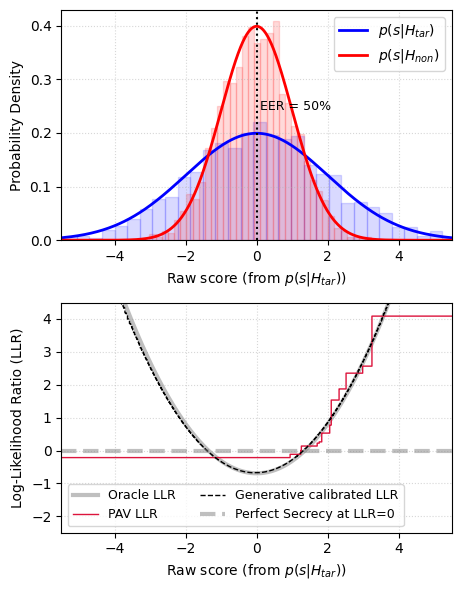

In [ ]:
####
# visualization
####
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.44/2, 6), sharex=False,
                               gridspec_kw={'height_ratios': [1.0, 1]})

# Top Subplot: True Generative Density Functions
ax1.plot(plot_axis, pdf_pos, label='$p(s|H_{tar})$', color='blue', linewidth=2)
ax1.plot(plot_axis, pdf_neg, label='$p(s|H_{non})$', color='red', linewidth=2)
ax1.hist(pos_samples, bins=40, density=True, alpha=0.15, color='blue', edgecolor='blue')
ax1.hist(neg_samples, bins=40, density=True, alpha=0.15, color='red', edgecolor='red')

ax1.set_ylabel('Probability Density')
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='upper right')

# Highlight the EER Threshold at the center crossover
ax1.axvline(0, color='black', linestyle=':', linewidth=1.5)
ax1.text(0.1, 0.25, 'EER = 50%', fontsize=9, verticalalignment='center')
ax1.set_xlabel('Raw score (from $p(s|H_{tar})$)')
ax1.set_xlim(-5.5, 5.5)

# Buttom Subplot: LLRs
# true LLR (oracle)
ax2.plot(plot_axis, true_continuous_llr, label='Oracle LLR',
         color='gray', alpha=0.5, linewidth=3)

# PAV LLR
ax2.step(sorted_scores, sorted_pav_llrs, where='mid', label='PAV LLR',
         color='crimson', linewidth=1.0)
# Generative LLR
ax2.step(sorted_scores, generative_calibrated_llr, where='mid', label='Generative calibrated LLR',
         color='black', linestyle='--', linewidth=1.0)

# Perfect Secrecy
ax2.axhline(0, color='gray', alpha=0.5, linestyle='--', linewidth=3, label='Perfect Secrecy at LLR=0')

ax2.set_xlabel('Raw score (from $p(s|H_{tar})$)')
ax2.set_ylabel('Log-Likelihood Ratio (LLR)')
ax2.set_xlim(-5.5, 5.5)
ax2.set_ylim(-2.5, 4.5)
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9, ncol=2)

plt.tight_layout()
plt.savefig('fig_eerllr_1.pdf', bbox_inches='tight')
plt.show()

# Demonstration 3 -- Rank-based metric

We show how rank-based metric can be cast into LLR

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, betabinom
from scipy.optimize import minimize


In [ ]:
# Generate random samples (the same as Demonstration 2)
np.random.seed(42)

# In this case, 50\% EER
mu_neg, sigma_neg = 0.0, 1.0
mu_pos, sigma_pos = 0.0, 2.0

# In this case, we sample data
# this corresponds to the size of evaluation dataset (M)
N_samples = 2000

# Generate finite empirical data streams
pos_samples = np.random.normal(mu_pos, sigma_pos, N_samples)
neg_samples = np.random.normal(mu_neg, sigma_neg, N_samples)


In [ ]:
# compute the rank k of each true speaker among the negative samples
ranks = []
for i in range(pos_samples.shape[0]):
    rank = 1 + np.sum(neg_samples > pos_samples[i])
    ranks.append(rank)
ranks = np.array(ranks)

# estimate the empirical rank histogram (p_tilde)
hist, bin_edges = np.histogram(ranks, bins=np.arange(1, N_samples + 2))
p_tilde = hist / np.sum(hist)


In [ ]:
# estiamte the rank probability using parametric approach
#  beta-infor dist., estimate the parameter
def loss_function(params, size=N_samples):
    alpha, beta = params
    if alpha <= 0 or beta <= 0:
        return 1e10
    # betabinom in scipy uses (n, a, b) where n is number of trials (N-1)
    # and localization shifts by 1 since ranks are 1-indexed
    k_indices = np.arange(1, size + 1)
    gamma = betabinom.pmf(k_indices - 1, size - 1, alpha, beta)
    gamma = np.clip(gamma, 1e-15, 1.0)
    # compute the likelihood using empirical p_tilde
    return -np.sum(p_tilde * np.log(gamma))

# estimate the parameter
res = minimize(loss_function, x0=[0.5, 5.0], method='Nelder-Mead')
alpha_opt, beta_opt = res.x

# compute the parametric estimation of rank probability: gamma_k
gamma_k = betabinom.pmf(ranks - 1, N_samples - 1, alpha_opt, beta_opt)


In [ ]:
####
# CONVERT rank probability to rank-LLR
####
# Apply the unified, permutation-consistent LLR mapping formula
rank_llr = np.log(N_samples - 1) + np.log(gamma_k / (1.0 - gamma_k))

# there may be cases with gammar_k = 0
# rank_llr2, _ = compute_llr_rank(pos_samples, neg_samples)

/tmp/ipykernel_2829/1824707391.py:5: RuntimeWarning: divide by zero encountered in log
  rank_llr = np.log(N_samples - 1) + np.log(gamma_k / (1.0 - gamma_k))


In [ ]:
# Compute oracle LLR using the oracle dist.
# Here, we only consider the positive samples
pos_density = norm.pdf(pos_samples, mu_pos, sigma_pos)
neg_density = norm.pdf(pos_samples, mu_neg, sigma_neg)
pos_samples_llr = np.log(pos_density / neg_density)

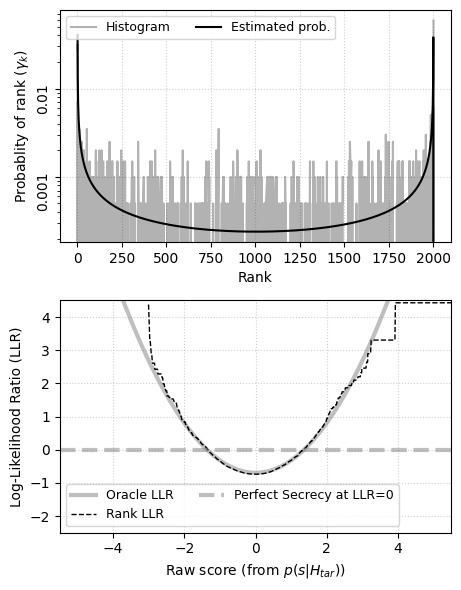

In [ ]:

####
# PLOT FIGURE
####
sort_idx = np.argsort(pos_samples)
sorted_scores = pos_samples[sort_idx]
sorted_labels = pos_samples[sort_idx]
sort_rank_idx = np.argsort(ranks)

#
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9.44/2, 6), gridspec_kw={'height_ratios': [1.0, 1]})

# subplot 1, plot score vs .rank
ax0.plot(ranks[sort_rank_idx], p_tilde, color='black', alpha=0.3, label='Histogram')
ax0.plot(ranks[sort_rank_idx], gamma_k[sort_rank_idx], color='black', label='Estimated prob.')
ax0.legend(loc='upper left', fontsize=9, ncol=2)
ax0.set_xlabel('Rank')
ax0.set_ylabel('Probablity of rank $(γ_k)$')
ax0.set_yscale('log')
ax0.set_yticks([0.001, 0.01])
ax0.set_yticklabels(['0.001', '0.01'], rotation=90)
ax0.grid(True, linestyle=':', alpha=0.6)

ax1.plot(sorted_scores, pos_samples_llr[sort_idx],
         label='Oracle LLR', color='gray', alpha=0.5, linewidth=3)
ax1.plot(sorted_scores, rank_llr[sort_idx], '--',
         label='Rank LLR', color='black', linewidth=1)
ax1.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=3, label='Perfect Secrecy at LLR=0')

ax1.set_xlabel('Raw score (from $p(s|H_{tar})$)')
ax1.set_ylabel('Log-Likelihood Ratio (LLR)')
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(loc='lower left', fontsize=9, ncol=2)
ax1.set_xlim(-5.5, 5.5)
ax1.set_ylim(-2.5, 4.5)


plt.tight_layout()
plt.savefig('fig_rankllr_1.pdf', bbox_inches='tight')
plt.show()

# Demonstration using VPC data

In [ ]:
# download the data
!tar -xzf Privacy-EER-data.tar.gz
#!find VPCAttackerChallengeScores -type f -name "scores"

# Unzip the data package downloaded together with the notebook

Downloading...
To: /content/Privacy-EER-data.tar.gz
100% 4.32M/4.32M [00:00<00:00, 48.3MB/s]
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, betabinom
from scipy.optimize import minimize
from scipy.stats import t

import pandas as pd

# data io to load from VPC data
def load_score_vpc(filename):
    data = pd.read_csv(filename, names=['speaker-id', 'file-id', 'score'], sep=' ')
    data['label'] = data.apply(lambda x: str(x['speaker-id']) == x['file-id'].split('-')[0], axis=1)
    pos_scores = data.query('label == True')['score'].to_numpy()
    neg_scores = data.query('label != True')['score'].to_numpy()
    return pos_scores, neg_scores


In [ ]:
def compute_llr_pav(pos_scores, neg_scores):
    # Execute the smoothed PAV script on the sorted data
    tar_llrs, non_llrs = optimal_llr(pos_scores, neg_scores, laplace=True, monotonicity_epsilon=0)
    return tar_llrs, non_llrs

def compute_llr_gen(pos_scores, neg_scores):
    # assume Gaussian distribution, estimate the mean and std,
    # calculate LLRs
    # Compute parameters directly from your provided input streams
    mu_pos_est, sigma_pos_est = np.mean(pos_scores), np.std(pos_scores)
    mu_neg_est, sigma_neg_est = np.mean(neg_scores), np.std(neg_scores)


    pos_llrs = np.log(norm.pdf(pos_scores, mu_pos_est, sigma_pos_est) /
                      norm.pdf(pos_scores, mu_neg_est, sigma_neg_est))
    neg_llrs = np.log(norm.pdf(neg_scores, mu_pos_est, sigma_pos_est) /
                      norm.pdf(neg_scores, mu_neg_est, sigma_neg_est))
    return pos_llrs, neg_llrs

def compute_llr_gen_t(pos_scores, neg_scores):
    # assume t-dist.
    nu_pos, loc_pos, scale_pos = t.fit(pos_scores)
    nu_neg, loc_neg, scale_neg = t.fit(neg_scores)

    #
    pos_llrs = np.log(t.pdf(pos_scores, df=nu_pos, loc=loc_pos, scale=scale_pos) /
                      t.pdf(pos_scores, df=nu_neg, loc=loc_neg, scale=scale_neg))

    # Evaluate directly at the background speaker's data entries
    neg_llrs = np.log(t.pdf(neg_scores, df=nu_pos, loc=loc_pos, scale=scale_pos) /
                      t.pdf(neg_scores, df=nu_neg, loc=loc_neg, scale=scale_neg))
    return pos_llrs, neg_llrs

def compute_llr_rank(pos_scores, neg_scores, use_empirical=False, floor=1e-09):
    # compute the rank k of each true speaker among the negative samples
    ranks = []
    N_samples = neg_scores.shape[0] + 1
    for i in range(pos_scores.shape[0]):
        rank = 1 + np.sum(neg_scores > pos_scores[i])
        ranks.append(rank)
    ranks = np.array(ranks)

    # estimate the empirical rank histogram (p_tilde)
    hist, bin_edges = np.histogram(ranks, bins=np.arange(1, N_samples + 2))
    p_tilde = hist / np.sum(hist)

    if use_empirical:
        gamma_k = p_tilde[ranks-1]
    else:
        # estiamte the rank probability using parametric approach
        #  beta-infor dist., estimate the parameter
        def loss_function(params, size = N_samples):
            alpha, beta = params
            if alpha <= 0 or beta <= 0:
                return 1e10
            # betabinom in scipy uses (n, a, b) where n is number of trials (N-1)
            # and localization shifts by 1 since ranks are 1-indexed
            k_indices = np.arange(1, size + 1)
            gamma = betabinom.pmf(k_indices - 1, size - 1, alpha, beta)
            gamma = np.clip(gamma, 1e-15, 1.0)
            # compute the likelihood using empirical p_tilde
            return -np.sum(p_tilde * np.log(gamma))

        # estimate the parameter
        res = minimize(loss_function, x0=[0.5, 5.0], method='Nelder-Mead')
        alpha_opt, beta_opt = res.x

        # compute the parametric estimation of rank probability: gamma_k
        gamma_k = betabinom.pmf(ranks - 1, N_samples - 1, alpha_opt, beta_opt)

    # smooth out zero probabilities
    #gamma_k[gamma_k < floor] += floor)
    ####
    # CONVERT rank probability to rank-LLR
    ####
    # Apply the unified, permutation-consistent LLR mapping formula
    pos_ranl_llr = np.log(N_samples - 1) + np.log(gamma_k / (1.0 - gamma_k))
    # we only compute llr for positive samples
    return pos_ranl_llr, None


def compute_epsilon(llrs):
    return np.max(np.abs(llrs))

In [ ]:
def plot_figure(pos_scores, neg_scores,
                pav_pos_llrs, pav_neg_llrs,
                gen_pos_llrs, gen_neg_llrs,
                gen_t_pos_llrs, gen_t_neg_llrs,
                rank_pos_llrs):
    # prepare for visualization
    N_pos = len(pos_scores)
    M_neg = len(neg_scores)

    eer, threshold = compute_eer(pos_scores, neg_scores)

    # combine them into a single array for visualization
    all_scores = np.concatenate([pos_scores, neg_scores])
    all_labels = np.concatenate([np.ones(N_pos), np.zeros(M_neg)])
    sort_idx = np.argsort(all_scores)
    sorted_scores = all_scores[sort_idx]
    sorted_labels = all_labels[sort_idx]
    sort_idx_pos_only = np.argsort(pos_scores)
    sort_idx_neg_only = np.argsort(neg_scores)

    # Separate sorted mapping flags back into ground-truth tracks
    pos_mask = (sorted_labels == 1)
    neg_mask = (sorted_labels == 0)

    # For plotting the score distributions
    mu_pos_est, sigma_pos_est = np.mean(pos_scores), np.std(pos_scores)
    mu_neg_est, sigma_neg_est = np.mean(neg_scores), np.std(neg_scores)
    min_score = min(all_scores) - 0.5
    max_score = max(all_scores) + 0.5
    plot_axis = np.linspace(min_score, max_score, 1000)

    # calculate the pdf
    pdf_pos_est = norm.pdf(plot_axis, mu_pos_est, sigma_pos_est)
    pdf_neg_est = norm.pdf(plot_axis, mu_neg_est, sigma_neg_est)

    # plotting
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(9.44/2, 6), sharex=True)

    # fig.1 score distribution
    ax0.hist(pos_scores, bins=40, density=True, alpha=0.25, color='blue', edgecolor='blue', label=f'Target')
    ax0.hist(neg_scores, bins=40, density=True, alpha=0.25, color='red', edgecolor='red', label=f'Nontar.')
    ax0.plot(plot_axis, pdf_pos_est, color='blue', linewidth=2)
    ax0.plot(plot_axis, pdf_neg_est, color='red', linewidth=2)
    ax0.set_ylabel('Probability Density', fontsize=10)
    ax0.grid(True, linestyle=':', alpha=0.5)
    ax0.legend(loc='upper left', fontsize=9)
    ax0.set_xlim([all_scores.min()*0.9, all_scores.max()*1.1])

    # Highlight the EER Threshold at the center crossover
    ax0.axvline(threshold, color='black', linestyle=':', linewidth=1.5)
    ax0.text(threshold, ax0.get_ylim()[1]*0.9, 'EER {:0.2f}%'.format(eer * 100), fontsize=9, verticalalignment='center')

    # Determine global vertical limits to handle flexible input data scales safely
    all_computed_llrs = np.concatenate([pav_pos_llrs, gen_pos_llrs])
    y_min = min(all_computed_llrs) - 1.0
    y_max = max(all_computed_llrs) + 1.0
    # leave some spaces for annotation
    x_min = sorted_scores[0] - 0.2 * (sorted_scores[-1] - sorted_scores[0])
    x_max = sorted_scores[-1] + 0.1 * (sorted_scores[-1] - sorted_scores[0])
    x_text = min(pos_scores) + 0.02 * (max(pos_scores) - min(pos_scores))

    # fig.1 sub, plot LLR
    ax1.axhline(0, color='gray', linestyle='--', linewidth=3, label='Perfect Secrecy')
    # Plot calibration overlays
    ax1.step(sorted_scores[pos_mask], pav_pos_llrs[sort_idx_pos_only], where='mid',
            color='k', linewidth=1.0, label='PAV')
    ax1.plot(sorted_scores[pos_mask], gen_pos_llrs[sort_idx_pos_only],
            color='b', linewidth=1.0, label='Gen.Gaus')
    ax1.plot(sorted_scores[pos_mask], gen_t_pos_llrs[sort_idx_pos_only],
            color='g', linewidth=1.0, label='Gen.t')
    ax1.plot(sorted_scores[pos_mask], rank_pos_llrs[sort_idx_pos_only],
             color='r', linewidth=1.0, label='Rank')


    for llr, name in zip(
        [pav_pos_llrs, gen_pos_llrs, gen_t_pos_llrs, rank_pos_llrs],
         ['PAV', 'Gen.Gaus.', 'Gen.t.', 'Rank']):

        epsilon_idx = np.argmax(np.abs(llr))
        epsilon = compute_epsilon(llr)
        ax1.annotate('ε_max({:s}):{:.2f}'.format(name, epsilon),
                xy=(pos_scores[epsilon_idx], llr[epsilon_idx]),
                xytext=(x_text, llr[epsilon_idx]*0.9),
                arrowprops=dict(facecolor='grey', arrowstyle='->', linestyle=':', linewidth=0.5),
                     fontsize=9, ha='left')

    #ax1.annotate('ε_max (perfect)=0',
    #             xy=(ax1.get_xlim()[0]+0.1, 0),
    #             xytext=(ax1.get_xlim()[0]+0.1, 2),
    #             arrowprops=dict(facecolor='k', arrowstyle='->'), fontsize=9)

    ax1.set_ylabel('Log-Likelihood Ratio (LLR)', fontsize=10)
    ax1.set_ylim(y_min, y_max)
    #ax1.set_xlim(x_min, x_max)
    ax1.grid(True, linestyle=':', alpha=0.5)
    ax1.legend(loc='lower right', fontsize=9)
    ax1.set_xlabel('Raw ASV Score ($s$)', fontsize=10)


    # --- Subplot 2: Negative Class LLR Space ---
    #ax2.axhline(0, color='gray', linestyle='--', linewidth=3)
    #ax2.step(sorted_scores[neg_mask], pav_neg_llrs[sort_idx_neg_only], where='mid',
    #         color='red', linewidth=1.0, label='PAV LLR')
    #ax2.plot(sorted_scores[neg_mask], gen_neg_llrs[sort_idx_neg_only],
    #         color='red', linewidth=1.0, linestyle=':', label='Gen.Calib.LLR')
    #ax2.set_xlabel('Raw ASV Score ($s$)', fontsize=10)
    #ax2.set_ylabel('Log-Likelihood Ratio (LLR)', fontsize=10)
    #ax2.set_ylim(y_min, y_max)
    #ax2.grid(True, linestyle=':', alpha=0.5)
    #ax2.legend(loc='lower center', fontsize=9, ncol=3)

    #plt.tight_layout()
    #plt.savefig('fig_calibrate.pdf', bbox_inches='tight')
    return fig, (ax0, ax1)

In [ ]:
# load the scores from test set, pool male and female scores
systems = {'B5':
           ['VPCAttackerChallengeScores/B5/exp/asv_anon_B5/libri_test_enrolls_B5_trials_m_B5/scores',
            'VPCAttackerChallengeScores/B5/exp/asv_anon_B5/libri_test_enrolls_B5_trials_f_B5/scores'],
           'T25-1':
           ['VPCAttackerChallengeScores/T25-1/exp/asv_anon_T25-1/libri_test_enrolls_T25-1-libri_test_trials_m_T25-1/scores',
            'VPCAttackerChallengeScores/T25-1/exp/asv_anon_T25-1/libri_test_enrolls_T25-1-libri_test_trials_f_T25-1/scores'],
           'B4':
           ['VPCAttackerChallengeScores/B4/exp/libri_test_enrolls_B4-libri_test_trials_m_B4/scores',
            'VPCAttackerChallengeScores/B4/exp/libri_test_enrolls_B4-libri_test_trials_f_B4/scores'],
           'T8-5':
           ['VPCAttackerChallengeScores/T8-5/exp/asv_anon_T8-5/libri_test_enrolls_T8-5-libri_test_trials_m_T8-5/scores',
            'VPCAttackerChallengeScores/T8-5/exp/asv_anon_T8-5/libri_test_enrolls_T8-5-libri_test_trials_f_T8-5/scores'],
           'B3':
           ['VPCAttackerChallengeScores/B3/exp/asv_anon_B3/libri_test_enrolls_B3-libri_test_trials_m_B3/scores',
            'VPCAttackerChallengeScores/B3/exp/asv_anon_B3/libri_test_enrolls_B3-libri_test_trials_f_B3/scores'],
           'T12-5':
           ['VPCAttackerChallengeScores/T12-5/exp/asv_anon_T12-5/libri_test_enrolls_T12-5-libri_test_trials_m_T12-5/scores',
            'VPCAttackerChallengeScores/T12-5/exp/asv_anon_T12-5/libri_test_enrolls_T12-5-libri_test_trials_f_T12-5/scores'],
           'T10-2':
           ['VPCAttackerChallengeScores/T10-2/exp/asv_anon_T10-2/libri_test_enrolls_T10-2-libri_test_trials_m_T10-2/scores',
            'VPCAttackerChallengeScores/T10-2/exp/asv_anon_T10-2/libri_test_enrolls_T10-2-libri_test_trials_f_T10-2/scores']
}

results = pd.DataFrame(np.zeros([len(systems), 5]), columns=['EER', 'Epsilon_pav', 'Epsilon_gen', 'Epsilon_gen_t','Epsilon_rank'], index=systems.keys())


B5
T25-1
B4
T8-5
B3
T12-5
T10-2


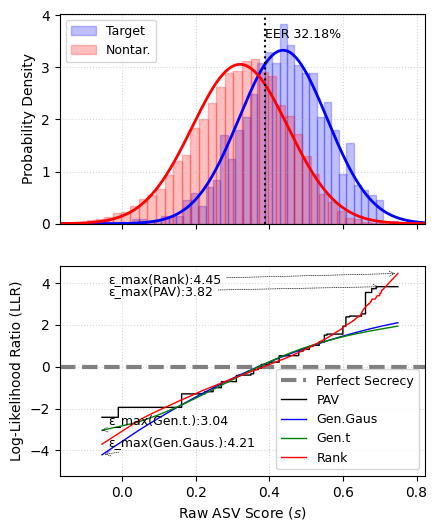

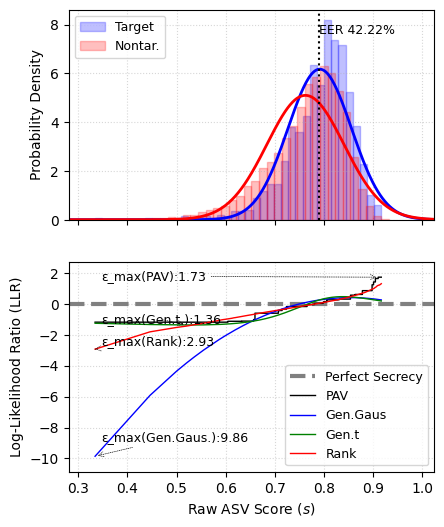

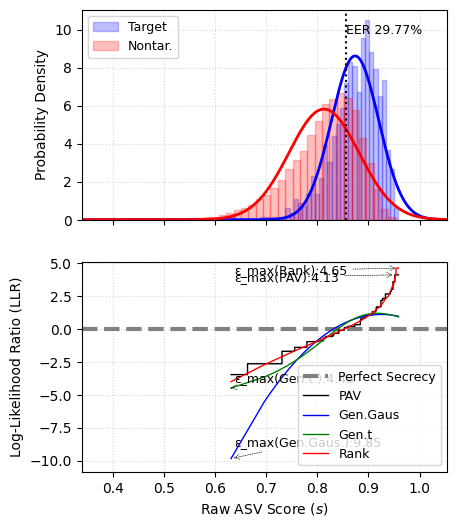

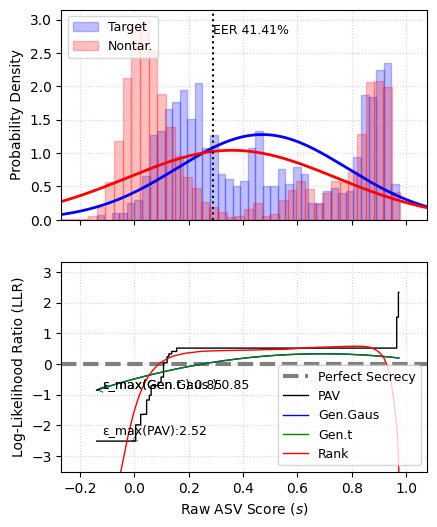

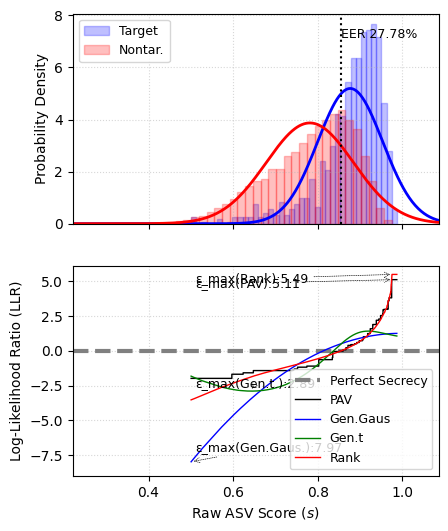

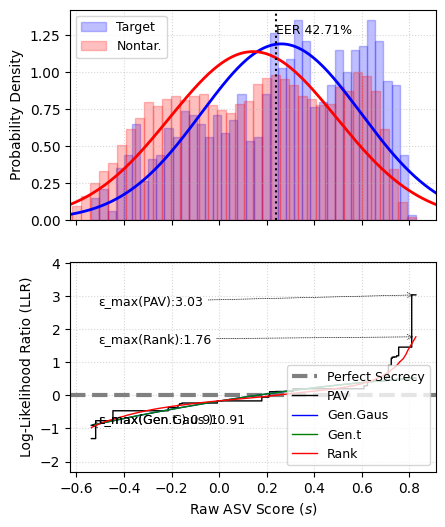

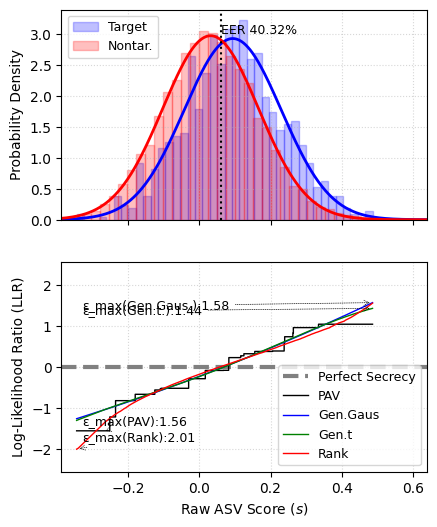

In [ ]:
for sys_name in systems.keys():
    print(sys_name)
    score_path = systems[sys_name]
    # get scores
    pos_scores_m, neg_scores_m = load_score_vpc(score_path[0])
    pos_scores_f, neg_scores_f = load_score_vpc(score_path[1])
    pos_scores = np.concatenate([pos_scores_m, pos_scores_f])
    neg_scores = np.concatenate([neg_scores_m, neg_scores_f])

    # compute_llr
    pav_pos_llrs, pav_neg_llrs = compute_llr_pav(pos_scores, neg_scores)
    gen_pos_llrs, gen_neg_llrs = compute_llr_gen(pos_scores, neg_scores)
    gen_t_pos_llrs, gen_t_neg_llrs = compute_llr_gen_t(pos_scores, neg_scores)
    rank_pos_llrs, _ = compute_llr_rank(pos_scores, neg_scores, use_empirical=False)

    #
    eer, threshold = compute_eer(pos_scores, neg_scores)
    epsilon_pav = compute_epsilon(pav_pos_llrs)
    epsilon_gen = compute_epsilon(gen_pos_llrs)
    epsilon_gen_t = compute_epsilon(gen_t_pos_llrs)
    epsilon_rank = compute_epsilon(rank_pos_llrs)

    results.loc[sys_name] = np.array([eer * 100, epsilon_pav, epsilon_gen, epsilon_gen_t, epsilon_rank])

    fig, axes = plot_figure(pos_scores, neg_scores, pav_pos_llrs, pav_neg_llrs, gen_pos_llrs, gen_neg_llrs, gen_t_pos_llrs, gen_t_neg_llrs, rank_pos_llrs)
    fig.savefig('fig_vpc_{:s}.pdf'.format(sys_name), bbox_inches='tight')
    #break

In [ ]:
results.sort_values(by='EER')

,EER,Epsilon_pav,Epsilon_gen,Epsilon_gen_t,Epsilon_rank
B3,27.783119,5.110307,7.969851,2.893243,5.485781
B4,29.769036,4.129477,9.853758,4.481570,4.649317
B5,32.178283,3.819322,4.207734,3.039551,4.449440
T10-2,40.319780,1.556650,1.576768,1.436308,2.005264
T8-5,41.408887,2.520883,0.853945,0.853947,8.952675
T25-1,42.221654,1.731582,9.861686,1.362840,2.928122
T12-5,42.712080,3.030865,0.907871,0.907812,1.764606


In [ ]:
latex_code = results.sort_values(by='EER').to_latex(index=True, caption="Solar System Data", label="tab:vpc", float_format="%.2f")

# 3. Print the result
print(latex_code)

\begin{table}
\caption{Solar System Data}
\label{tab:vpc}
\begin{tabular}{lrrrrr}
\toprule
 & EER & Epsilon_pav & Epsilon_gen & Epsilon_gen_t & Epsilon_rank \\
\midrule
B3 & 27.78 & 5.11 & 7.97 & 2.89 & 5.49 \\
B4 & 29.77 & 4.13 & 9.85 & 4.48 & 4.65 \\
B5 & 32.18 & 3.82 & 4.21 & 3.04 & 4.45 \\
T10-2 & 40.32 & 1.56 & 1.58 & 1.44 & 2.01 \\
T8-5 & 41.41 & 2.52 & 0.85 & 0.85 & 8.95 \\
T25-1 & 42.22 & 1.73 & 9.86 & 1.36 & 2.93 \\
T12-5 & 42.71 & 3.03 & 0.91 & 0.91 & 1.76 \\
\bottomrule
\end{tabular}
\end{table}



# Misc

early version of the code

<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
<>:35: SyntaxWarning: invalid escape sequence '\m'
<>:47: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1482/2378819481.py:35: SyntaxWarning: invalid escape sequence '\m'
  ax1.text(0.1, 0.25, 'EER Threshold ($\mu=0$)\nError Rates = 50%',
/tmp/ipykernel_1482/2378819481.py:47: SyntaxWarning: invalid escape sequence '\m'
  ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Perfect Secrecy ($\mathrm{LLR}=0$)')


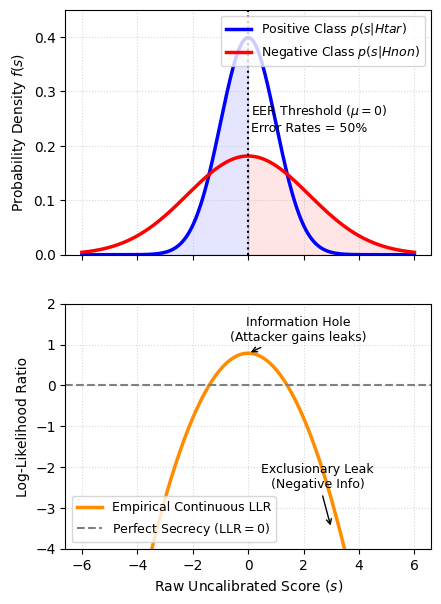

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

####
# Example
####
# Both distributions share the same mean, which forces EER = 50%
# positive class
mu_pos, sigma_pos = 0.0, 1.0
# negative class
mu_neg, sigma_neg = 0.0, 2.2

# use scores from -6 to 6 as example
scores = np.linspace(-6, 6, 1000)

# Compute probability density functions of the scores
# on the known score dist.
pdf_pos = norm.pdf(scores, mu_pos, sigma_pos)
pdf_neg = norm.pdf(scores, mu_neg, sigma_neg)

# then ideal calibration, LLR(s) = ln( f(s|Pos) / f(s|Neg) )
llr = np.log(pdf_pos / pdf_neg)

####
# Plotting
####
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.44/2, 7), sharex=True,
                               gridspec_kw={'height_ratios': [1, 1]})
ax1.plot(scores, pdf_pos, label='Positive Class $p(s | H tar)$', color='blue', linewidth=2.5)
ax1.plot(scores, pdf_neg, label='Negative Class $p(s | H non)$', color='red', linewidth=2.5)

# Highlight the EER Threshold at the center crossover
ax1.axvline(0, color='black', linestyle=':', linewidth=1.5)
ax1.text(0.1, 0.25, 'EER Threshold ($\mu=0$)\nError Rates = 50%',
         fontsize=9, verticalalignment='center')
# Shading the overlapping error regions to visually anchor EER = 50%
ax1.fill_between(scores, 0, pdf_pos, where=(scores < 0), color='blue', alpha=0.1)
ax1.fill_between(scores, 0, pdf_neg, where=(scores > 0), color='red', alpha=0.1)

ax1.set_ylabel('Probability Density $f(s)$', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.5)
ax1.legend(loc='upper right', fontsize=9)
ax1.set_ylim(0, 0.45)

ax2.plot(scores, llr, label='Empirical Continuous LLR', color='darkorange', linewidth=2.5)
ax2.axhline(0, color='gray', linestyle='--', linewidth=1.5, label='Perfect Secrecy ($\mathrm{LLR}=0$)')
ax2.annotate('Information Hole\n(Attacker gains leaks)', xy=(0, 0.78), xytext=(1.8, 1.1),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=9, ha='center')
ax2.annotate('Exclusionary Leak\n(Negative Info)', xy=(3, -3.5), xytext=(2.5, -2.5),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=9, ha='center')
ax2.set_xlabel('Raw Uncalibrated Score ($s$)', fontsize=10)
ax2.set_ylabel('Log-Likelihood Ratio', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.5)
ax2.legend(loc='lower left', fontsize=9)
ax2.set_ylim(-4, 2)
plt.show()


# Acknowledgement

We thank the authors of all the functions imported in this notebook.

We also thank the VPC organizers providing the score files.